In [ ]:
# # Part 2: Hierarchical Agglomerative Clustering
# This notebook explores the "Tree-based" relationship between customers.
# We focus on the Dendrogram to understand nested relationships and generate a profile heatmap.

# %% [1] Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

In [ ]:
# %% [2] Data Ingestion & Exploratory Analysis
# Load the dataset (Ensure 'Mall_Customers.csv' is in your directory)
try:
    df = pd.read_csv('Mall_Customers.csv')
    print("Dataset successfully loaded.")
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found. Please check the file path.")

# Preview the data
print(f"Shape: {df.shape}")
display(df.head())

Dataset successfully loaded.
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Basic statistics check
display(df.describe())

# %% [3] Professional Preprocessing
# Selecting features: Age, Annual Income, and Spending Score
X = df.iloc[:, [2, 3, 4]].values

# Feature Scaling: Essential for Hierarchical Clustering as it uses Euclidean distances
# We want to ensure 'Annual Income' (high range) doesn't dominate 'Age' (low range)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled and prepared for clustering.")

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Data scaled and prepared for clustering.


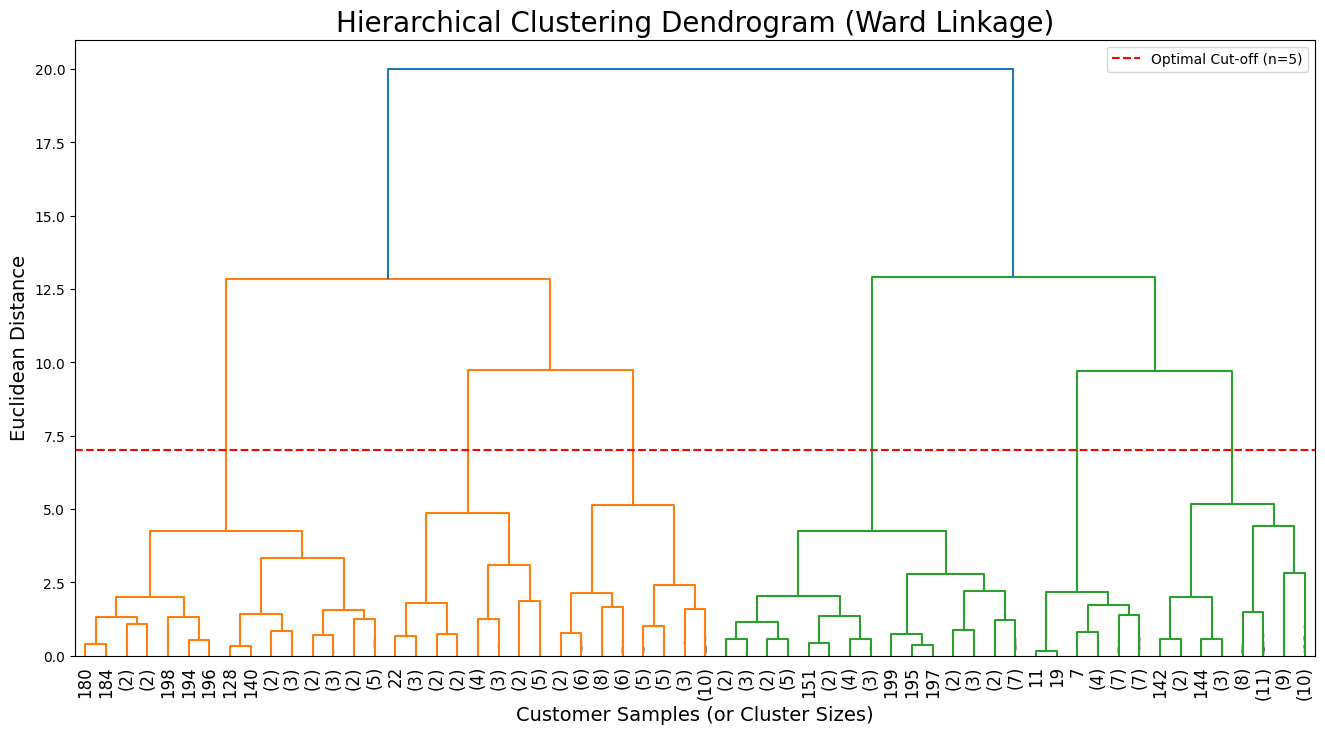

In [ ]:
# %% [4] The Dendrogram (Finding the Optimal Number of Clusters)
plt.figure(figsize=(16, 8))

# Using 'Ward' Linkage: Minimizes the variance of clusters being merged
# This is generally the most effective method for spherical-like clusters
Z = sch.linkage(X_scaled, method='ward')

# We truncate the tree to 5 levels to make it readable
dendrogram = sch.dendrogram(
    Z,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=12,
    show_contracted=True
)

# Adding a horizontal threshold line to determine the number of clusters
# The largest vertical distance not intersected by a horizontal line is the optimal cut
plt.axhline(y=7, color='r', linestyle='--', label='Optimal Cut-off (n=5)')

plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=20)
plt.xlabel('Customer Samples (or Cluster Sizes)', fontsize=14)
plt.ylabel('Euclidean Distance', fontsize=14)
plt.legend()
plt.show()

In [ ]:
# %% [5] Model Execution
# Based on the dendrogram, 5 clusters is the most logical choice
n_clusters = 5
hc = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
cluster_labels = hc.fit_predict(X_scaled)

# Add labels back to the original dataframe for profiling
df['Cluster'] = cluster_labels

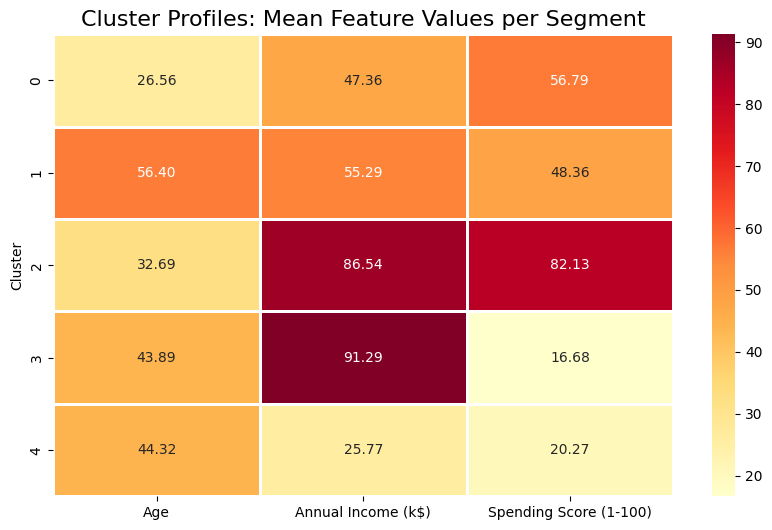

In [ ]:
# %% [6] Cluster Profiling & Heatmap Analysis
# This step explains "WHO" is in each cluster
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=2)
plt.title(f'Cluster Profiles: Mean Feature Values per Segment', fontsize=16)
plt.show()

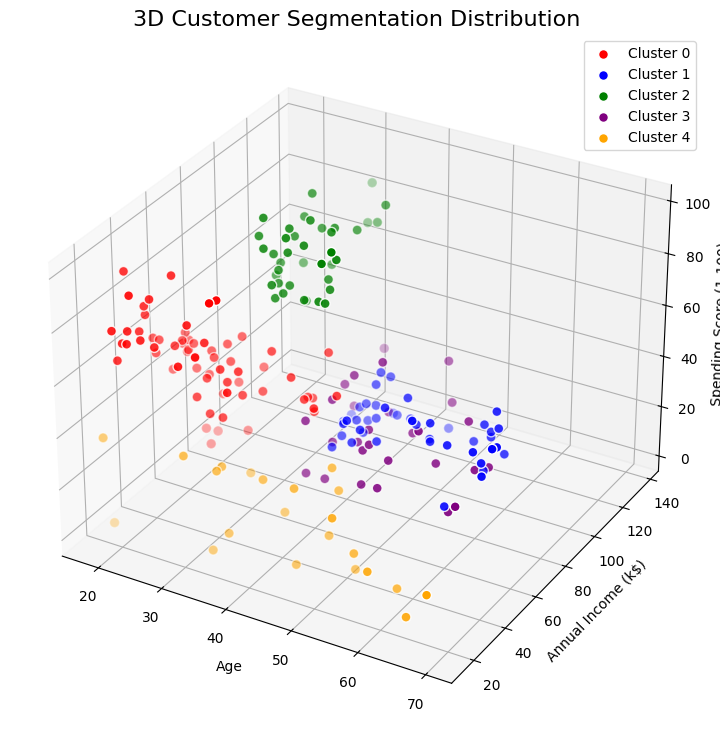

In [ ]:
# %% [7] 3D Visual Representation
# Since we have 3 features (Age, Income, Spending), a 3D plot is the best way to see the truth
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(n_clusters):
    ax.scatter(X[cluster_labels == i, 0],
               X[cluster_labels == i, 1],
               X[cluster_labels == i, 2],
               s=50, c=colors[i], label=f'Cluster {i}', edgecolors='w')

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Customer Segmentation Distribution', fontsize=16)
plt.legend()
plt.show()

In [ ]:
# %% [8] Statistical Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil_score = silhouette_score(X_scaled, cluster_labels)
dbi_score = davies_bouldin_score(X_scaled, cluster_labels)

print("-" * 40)
print(f"HIERARCHICAL CLUSTERING METRICS")
print("-" * 40)
print(f"Silhouette Score: {sil_score:.4f} (Higher is better, max 1.0)")
print(f"Davies-Bouldin Index: {dbi_score:.4f} (Lower is better)")
print("-" * 40)

----------------------------------------
HIERARCHICAL CLUSTERING METRICS
----------------------------------------
Silhouette Score: 0.3900 (Higher is better, max 1.0)
Davies-Bouldin Index: 0.9163 (Lower is better)
----------------------------------------
